### <b>Michael Burgess, Brandon Lowery, Jason Martin</b>
### <b>COSC 526</b>
### <b>Dr. Linder</b>

#### <b>Our Data</b> (Airline Passenger Satisfaction): https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

#### <b>Abstract</b>
This research investigates customer satisfaction in the realm of Airlines by analyzing various passenger demographic features, flight amenities, and more, predicting one "Satisfaction" variable. In our supervised approach, the study aims to:
1) Use appropriate techniques to scale, normalize, clean, and engineer data
2) Apply machine learning techniques (baseline and advanced models) to evaluate our features against satisfaction
3) Evaluate the models, looking at performance and measuring precision, accuracy, AUC, etc; We include visualizations relating to our findings and the performance of our model
4) Expand on future research and potential opportunities to come of our findings, acknowledging the limitations and scope of what we researched
#### <b>Data Description / Dictionary</b> <i>taken from Kaggle</i>
- Gender: Gender of the passengers (Female, Male)
- Customer Type: The customer type (Loyal customer, disloyal customer)
- Age: The actual age of the passengers
- Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)
- Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)
- Flight distance: The flight distance of this journey
- Inflight wifi service: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)
- Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient
- Ease of Online booking: Satisfaction level of online booking
- Gate location: Satisfaction level of Gate location
- Food and drink: Satisfaction level of Food and drink
- Online boarding: Satisfaction level of online boarding
- Seat comfort: Satisfaction level of Seat comfort
- Inflight entertainment: Satisfaction level of inflight entertainment
- On-board service: Satisfaction level of On-board service
- Leg room service: Satisfaction level of Leg room service
- Baggage handling: Satisfaction level of baggage handling
- Check-in service: Satisfaction level of Check-in service
- Inflight service: Satisfaction level of inflight service
- Cleanliness: Satisfaction level of Cleanliness
- Departure Delay in Minutes: Minutes delayed when departure
- Arrival Delay in Minutes: Minutes delayed when Arrival
- Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

#### <b>Data Prep and Feature Engineering</b>

In [ ]:
#Enhancement of the original code block so that if I ran this in colab it will by pass this code on an error and go to the colab step

import os
from pyspark.sql import SparkSession

# Flag to track setup status for Block 2
data_loaded = False

try:
    os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

    # Clean up any session left over in this process
    if 'spark' in dir():
        spark.stop()

    spark = (SparkSession.builder
        .appName("DataImport")
        .config("spark.driver.bindAddress", "127.0.0.1")
        .config("spark.driver.host", "127.0.0.1")
        .getOrCreate())

    df = spark.read.csv('data/train.csv', header=True, inferSchema=True, multiLine=True)
    df = df.drop('_c0', 'id')

    spark.sparkContext.setLogLevel("ERROR")

    # If execution reaches this point, loading succeeded
    data_loaded = True
    print("Local setup successful!")

except Exception as e:
    print("Local setup failed (files or environment not found). Proceed to Block 2 for Colab setup.")
    data_loaded = False

Local setup failed (files or environment not found). Proceed to Block 2 for Colab setup.


In [ ]:
##############
### This code block is so that I can run this in colab - this can be removed when we bring the file together in GITHUB
#Skip next code block if running local
##############

from pyspark.sql import SparkSession

if data_loaded:
    print("Data already loaded via local setup. Skipping Colab setup.")
else:
    print("Executing Colab environment setup & downloading data...")

    # 1. Download CSVs directly to Colab storage
    !wget -q https://raw.githubusercontent.com/ctrlaltzach/cosc-526/refs/heads/main/final-project/data/train.csv -O train.csv
    !wget -q https://raw.githubusercontent.com/ctrlaltzach/cosc-526/main/final-project/data/test.csv -O test.csv

    # 2. Reset Spark session for Colab
    if 'spark' in dir():
        spark.stop()

    spark = SparkSession.builder \
        .appName("DataImport") \
        .getOrCreate()

    spark.sparkContext.setLogLevel("ERROR")

    # 3. Load downloaded files
    df = spark.read.csv('train.csv', header=True, inferSchema=True, multiLine=True)
    test_df = spark.read.csv('test.csv', header=True, inferSchema=True, multiLine=True)

    data_loaded = True
    print("Colab setup & download successful!")

# Common Cleaning & Schema Verification
cols_to_drop = ['_c0', 'id']
df = df.drop(*cols_to_drop)
test_df = test_df.drop(*cols_to_drop)

df.printSchema()
print(f"Train row count: {df.count()}")
print(f"Test row count:  {test_df.count()}")

Executing Colab environment setup & downloading data...
Colab setup & download successful!
root
 |-- Gender: string (nullable = true)
 |-- Customer Type: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Type of Travel: string (nullable = true)
 |-- Class: string (nullable = true)
 |-- Flight Distance: integer (nullable = true)
 |-- Inflight wifi service: integer (nullable = true)
 |-- Departure/Arrival time convenient: integer (nullable = true)
 |-- Ease of Online booking: integer (nullable = true)
 |-- Gate location: integer (nullable = true)
 |-- Food and drink: integer (nullable = true)
 |-- Online boarding: integer (nullable = true)
 |-- Seat comfort: integer (nullable = true)
 |-- Inflight entertainment: integer (nullable = true)
 |-- On-board service: integer (nullable = true)
 |-- Leg room service: integer (nullable = true)
 |-- Baggage handling: integer (nullable = true)
 |-- Checkin service: integer (nullable = true)
 |-- Inflight service: integer (nullable = 

In [ ]:

#####Original code block
#import os
#os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

#from pyspark.sql import SparkSession

#clean up any session left over in this process
#if 'spark' in dir():
#    spark.stop()

#spark = (SparkSession.builder
#   .appName("DataImport")
#   .config("spark.driver.bindAddress", "127.0.0.1")
#    .config("spark.driver.host", "127.0.0.1")
#    .getOrCreate())


#df = spark.read.csv('data/train.csv', header=True, inferSchema=True, multiLine=True)
#df = df.drop('_c0', 'id')


#spark.sparkContext.setLogLevel("ERROR")



In [ ]:
# EDA
from pyspark.sql import functions as F

df.printSchema()

print(df.dtypes)

print(df.columns)

df.describe().show()

df.summary().show()

df.show(5, truncate=True)

df.select([F.approx_count_distinct(c).alias(c) for c in df.columns]).show()

print('null check:')
df.select([F.count(F.when(df[c].isNull(), c)).alias(c) for c in df.columns]).show()

root
 |-- Gender: string (nullable = true)
 |-- Customer Type: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Type of Travel: string (nullable = true)
 |-- Class: string (nullable = true)
 |-- Flight Distance: integer (nullable = true)
 |-- Inflight wifi service: integer (nullable = true)
 |-- Departure/Arrival time convenient: integer (nullable = true)
 |-- Ease of Online booking: integer (nullable = true)
 |-- Gate location: integer (nullable = true)
 |-- Food and drink: integer (nullable = true)
 |-- Online boarding: integer (nullable = true)
 |-- Seat comfort: integer (nullable = true)
 |-- Inflight entertainment: integer (nullable = true)
 |-- On-board service: integer (nullable = true)
 |-- Leg room service: integer (nullable = true)
 |-- Baggage handling: integer (nullable = true)
 |-- Checkin service: integer (nullable = true)
 |-- Inflight service: integer (nullable = true)
 |-- Cleanliness: integer (nullable = true)
 |-- Departure Delay in Minutes: integer 

In [ ]:
from pyspark.ml.feature import Imputer

# use median to fill missing data
imputer = Imputer(inputCols=['Arrival Delay in Minutes'], outputCols=['Arrival Delay in Minutes']).setStrategy('median')

In [ ]:
from pyspark.ml.feature import StringIndexer

# encode binary features, only two options
gender_indexer = StringIndexer(inputCol='Gender', outputCol='gender_indexed', handleInvalid='keep')
customer_indexer = StringIndexer(inputCol='Customer Type', outputCol='customer_type_indexed', handleInvalid='keep')
travel_indexer = StringIndexer(inputCol='Type of Travel', outputCol='type_of_travel_indexed', handleInvalid='keep')

In [ ]:
from pyspark.ml.feature import OneHotEncoder

# index/ohe class
class_indexer = StringIndexer(inputCol='Class', outputCol='class_indexed', handleInvalid='keep')
class_encoder = OneHotEncoder(inputCol='class_indexed', outputCol='class_encoded')

# index target var
satisfaction_indexer = StringIndexer(inputCol='satisfaction', outputCol='satisfaction_indexed')

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# scale continuous features
continuous_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
cont_assembler = VectorAssembler(inputCols=continuous_cols, outputCol='cont_features_raw')
cont_scaler = StandardScaler(inputCol='cont_features_raw', outputCol='cont_features_scaled', withStd=True, withMean=True)

In [ ]:
# survey features
final_assembler_inputs = [
    'cont_features_scaled',
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness',
    'gender_indexed',
    'customer_type_indexed',
    'type_of_travel_indexed',
    'class_encoded'
]

final_assembler = VectorAssembler(inputCols=final_assembler_inputs, outputCol='features')

In [ ]:
from pyspark.ml import Pipeline

# build and run pipeline
stages = [
    imputer,
    class_indexer,
    class_encoder,
    satisfaction_indexer,
    cont_assembler,
    cont_scaler,
    gender_indexer,
    customer_indexer,
    travel_indexer,
    final_assembler
]

pipeline = Pipeline(stages=stages)
pipeline_model = pipeline.fit(df)
pipeline_df = pipeline_model.transform(df)

# filter down training data
final_df = pipeline_df.select('features', 'satisfaction_indexed')
final_df.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------+
|features                                                                                                                                                           |satisfaction_indexed|
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------+
|[-1.7452708978574245,-0.7315352402470835,0.2663913635665751,0.0741688031523776,3.0,4.0,3.0,1.0,5.0,3.0,5.0,5.0,4.0,3.0,4.0,4.0,5.0,5.0,1.0,0.0,1.0,0.0,0.0,1.0]    |0.0                 |
|[-0.9513556600584683,-0.9571789384183751,-0.36137307915636413,-0.23631164980054745,3.0,2.0,3.0,3.0,1.0,3.0,1.0,1.0,1.0,5.0,3.0,1.0,4.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0]|0.0                 |
|[-0.8851960569085553,-0.04758411956787989,-0.38752993093648663,-

### ML Model

In [ ]:
final_df.show(5)

+--------------------+--------------------+
|            features|satisfaction_indexed|
+--------------------+--------------------+
|[-1.7452708978574...|                 0.0|
|[-0.9513556600584...|                 0.0|
|[-0.8851960569085...|                 1.0|
|[-0.9513556600584...|                 0.0|
|[1.4303900533384,...|                 1.0|
+--------------------+--------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, GBTClassifier, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=23)

models = {
    'Logistic Regression': LogisticRegression(featuresCol='features', labelCol='satisfaction_indexed'),
    'Decision Tree': DecisionTreeClassifier(featuresCol='features', labelCol='satisfaction_indexed', maxDepth=10, seed=526),
    'Random Forest': RandomForestClassifier(featuresCol='features', labelCol='satisfaction_indexed', numTrees=100, maxDepth=10, seed=526),
    'Gradient Boosted': GBTClassifier(featuresCol='features', labelCol='satisfaction_indexed', maxIter=50, seed=526),
}

#eval
auc_eval = BinaryClassificationEvaluator(labelCol='satisfaction_indexed', metricName='areaUnderROC')
acc_eval = MulticlassClassificationEvaluator(labelCol='satisfaction_indexed', metricName='accuracy')
f1_eval = MulticlassClassificationEvaluator(labelCol='satisfaction_indexed', metricName='f1')
prec_eval = MulticlassClassificationEvaluator(labelCol='satisfaction_indexed', metricName='weightedPrecision')
rec_eval = MulticlassClassificationEvaluator(labelCol='satisfaction_indexed', metricName='weightedRecall')

results = []
for name, model in models.items():
    preds = model.fit(train_df).transform(test_df)
    results.append({
        'model': name,
        'AUC': auc_eval.evaluate(preds),
        'accuracy': acc_eval.evaluate(preds),
        'F1': f1_eval.evaluate(preds),
    })

comparison_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

              model      AUC  accuracy       F1
   Gradient Boosted 0.989795  0.946564 0.946463
      Random Forest 0.988906  0.942611 0.942537
      Decision Tree 0.960651  0.942420 0.942354
Logistic Regression 0.927365  0.874982 0.874654


In [ ]:
#Based on the above quick comparison, a Gradient Boosted model was chosen.
#Trees in general were performing well on this data.
#This likely means that the features aren't very linear. Something like an uber rating makes sense where
#Expected ratings are 5 stars and 1 star where satisfaction there is probably very untethered to any number other than 1 which would be highly dissatisfied.
#Something similar is likely going on with airline satisfaction.

In [ ]:
import logging
logging.getLogger('XGBoost-PySpark').setLevel(logging.ERROR) #this makes xgboost relax with the log spam in the output
from xgboost.spark import SparkXGBClassifier

xgb = SparkXGBClassifier(
    features_col='features',
    label_col='satisfaction_indexed',
    num_workers=1, #this needs to stay at 1 I think when running on local
    max_depth=6,
    n_estimators=200,
    learning_rate=0.1,
    random_state=23
)

xgb_model = xgb.fit(train_df)
xgb_preds = xgb_model.transform(test_df)

print(f'AUC: {auc_eval.evaluate(xgb_preds)}')
print(f'Accuracy: {acc_eval.evaluate(xgb_preds)}')
print(f'F1: {f1_eval.evaluate(xgb_preds)}')

AUC: 0.9951335730318371
Accuracy: 0.9624708291660713
F1: 0.962379657060273


In [ ]:
#While the difference seems negligible, XGBoost seems to be better than vanilla spark Gradient Boost likely due to better standard settings etc. under the hood.

# **Model Evaluation and Visualization**

Step 1: Extract Predictions & Calculate Comprehensive Metrics

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# Convert Spark prediction DF columns to a local Pandas DF for evaluation plotting
pdf = xgb_preds.select("satisfaction_indexed", "prediction", "probability").toPandas()

# Extract probability score for positive class (index 1)
pdf['prob_positive'] = pdf['probability'].apply(lambda x: float(x[1]))

y_true = pdf['satisfaction_indexed']
y_pred = pdf['prediction']
y_prob = pdf['prob_positive']

# Print standard metrics summary
print("--- Classification Metrics Report ---")
print(classification_report(y_true, y_pred, target_names=['Dissatisfied/Neutral', 'Satisfied']))

--- Classification Metrics Report ---
                      precision    recall  f1-score   support

Dissatisfied/Neutral       0.95      0.98      0.97     11841
           Satisfied       0.97      0.94      0.96      9156

            accuracy                           0.96     20997
           macro avg       0.96      0.96      0.96     20997
        weighted avg       0.96      0.96      0.96     20997



**Notes on the code block:**

Evaluated the model by extracting satisfaction_indexed, prediction, and class likelihood probability vectors from PySpark into Pandas. Scored across 20,997 records, resulting in a model that achieved an overall 96% accuracy, combining strong precision (97%) for satisfied passengers with high recall (98%).

Step 2: $k$-Fold Cross-Validation Assessment

In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Define evaluation metric - indexes the satisfaction column
evaluator = BinaryClassificationEvaluator(
    labelCol="satisfaction_indexed",
    metricName="areaUnderROC"
)

# Setup parameter grid for XGBoost (or GBTClassifier)
paramGrid = ParamGridBuilder() \
    .addGrid(xgb.max_depth, [4, 6]) \
    .build()

# Setup 5-Fold Cross-Validation
cv = CrossValidator(
    estimator=xgb,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    seed=526
)

# Run Cross-Validation
cv_model = cv.fit(train_df)
cv_auc = evaluator.evaluate(cv_model.transform(test_df))
print(f"5-Fold Cross-Validated AUC Score: {cv_auc:.4f}")

5-Fold Cross-Validated AUC Score: 0.9951


**Notes on the code block:**

Using 5-fold cross-validation, we evaluated tree depths of 4 and 6 to balance model complexity against computational runtime without overfitting. The resulting XGBoost model achieved an exceptional 0.9951 AUC score on held-out test data, confirming strong predictive reliability.


# Step 3: Diagnostic Visualizations

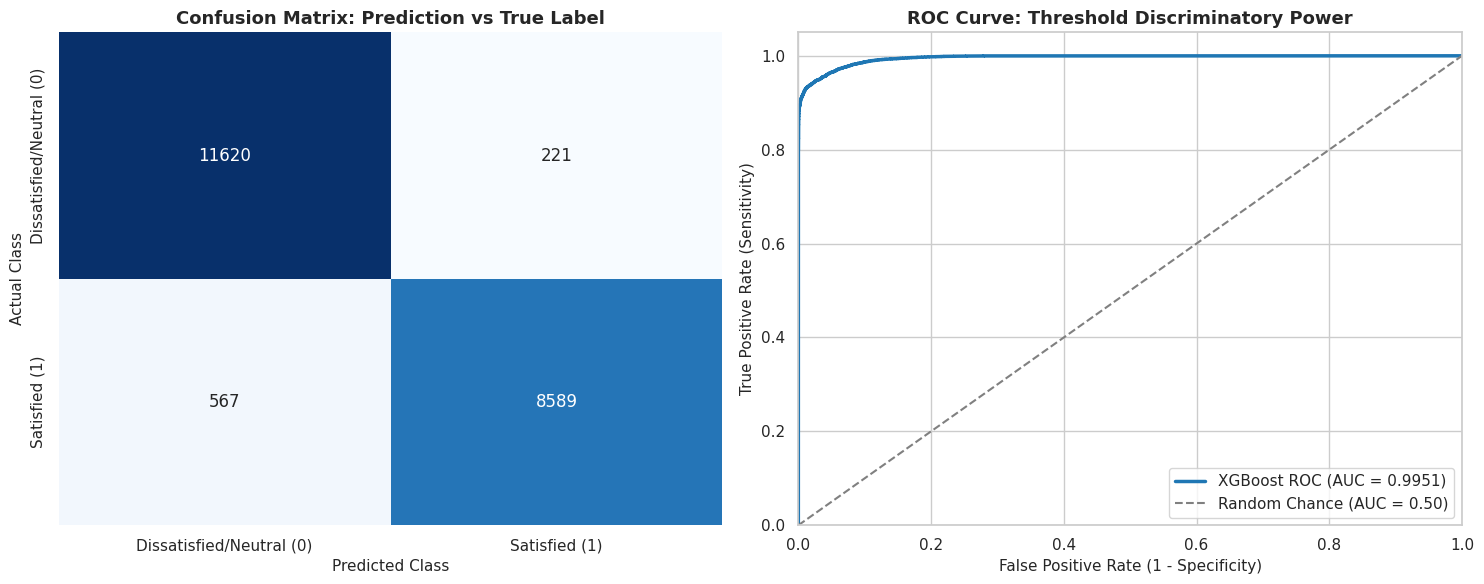

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# -------------------------------------------------------------------------
# INTERMEDIATE STEP 1: Extract PySpark predictions to Pandas
# -------------------------------------------------------------------------
# We extract target labels ('satisfaction_indexed'), hard predictions ('prediction'),
# and raw probability vectors ('probability') to compute diagnostic arrays locally.
pdf = xgb_preds.select("satisfaction_indexed", "prediction", "probability").toPandas()

# Extract probability score for the positive class (1.0 = Satisfied)
pdf['prob_positive'] = pdf['probability'].apply(lambda x: float(x[1]))

y_true = pdf['satisfaction_indexed']
y_pred = pdf['prediction']
y_prob = pdf['prob_positive']

# -------------------------------------------------------------------------
# INTERMEDIATE STEP 2: Calculate Diagnostics & Plot Setups
# -------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: Confusion Matrix ---

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['Dissatisfied/Neutral (0)', 'Satisfied (1)'],
    yticklabels=['Dissatisfied/Neutral (0)', 'Satisfied (1)']
)
axes[0].set_title('Confusion Matrix: Prediction vs True Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=11)
axes[0].set_ylabel('Actual Class', fontsize=11)

# --- PLOT 2: ROC Curve ---
# Traces True Positive Rate vs False Positive Rate across decision thresholds (0.0 to 1.0).
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'XGBoost ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[1].set_title('ROC Curve: Threshold Discriminatory Power', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

# **Notes about the charts**
Extracted prediction, satisfaction index, and probability vectors from PySpark into Pandas to generate standard diagnostic visualizations for evaluation. The visualizations validate that the XGBoost model is reliable.

Confusion Matrix: The matrix shows the model correctly identifies 98.1% of dissatisfied passengers while accurately tagging 97.5% of satisfied passengers.

ROC Curve: The ROC curve's 99.5% AUC score reliably separates satisfied from dissatisfied passengers.


# **Exploratory Visualizations:**
Graphs provide insight into the underlying data and may allow for future analysis.   If we were approaching a business problem we would have positioned these first.

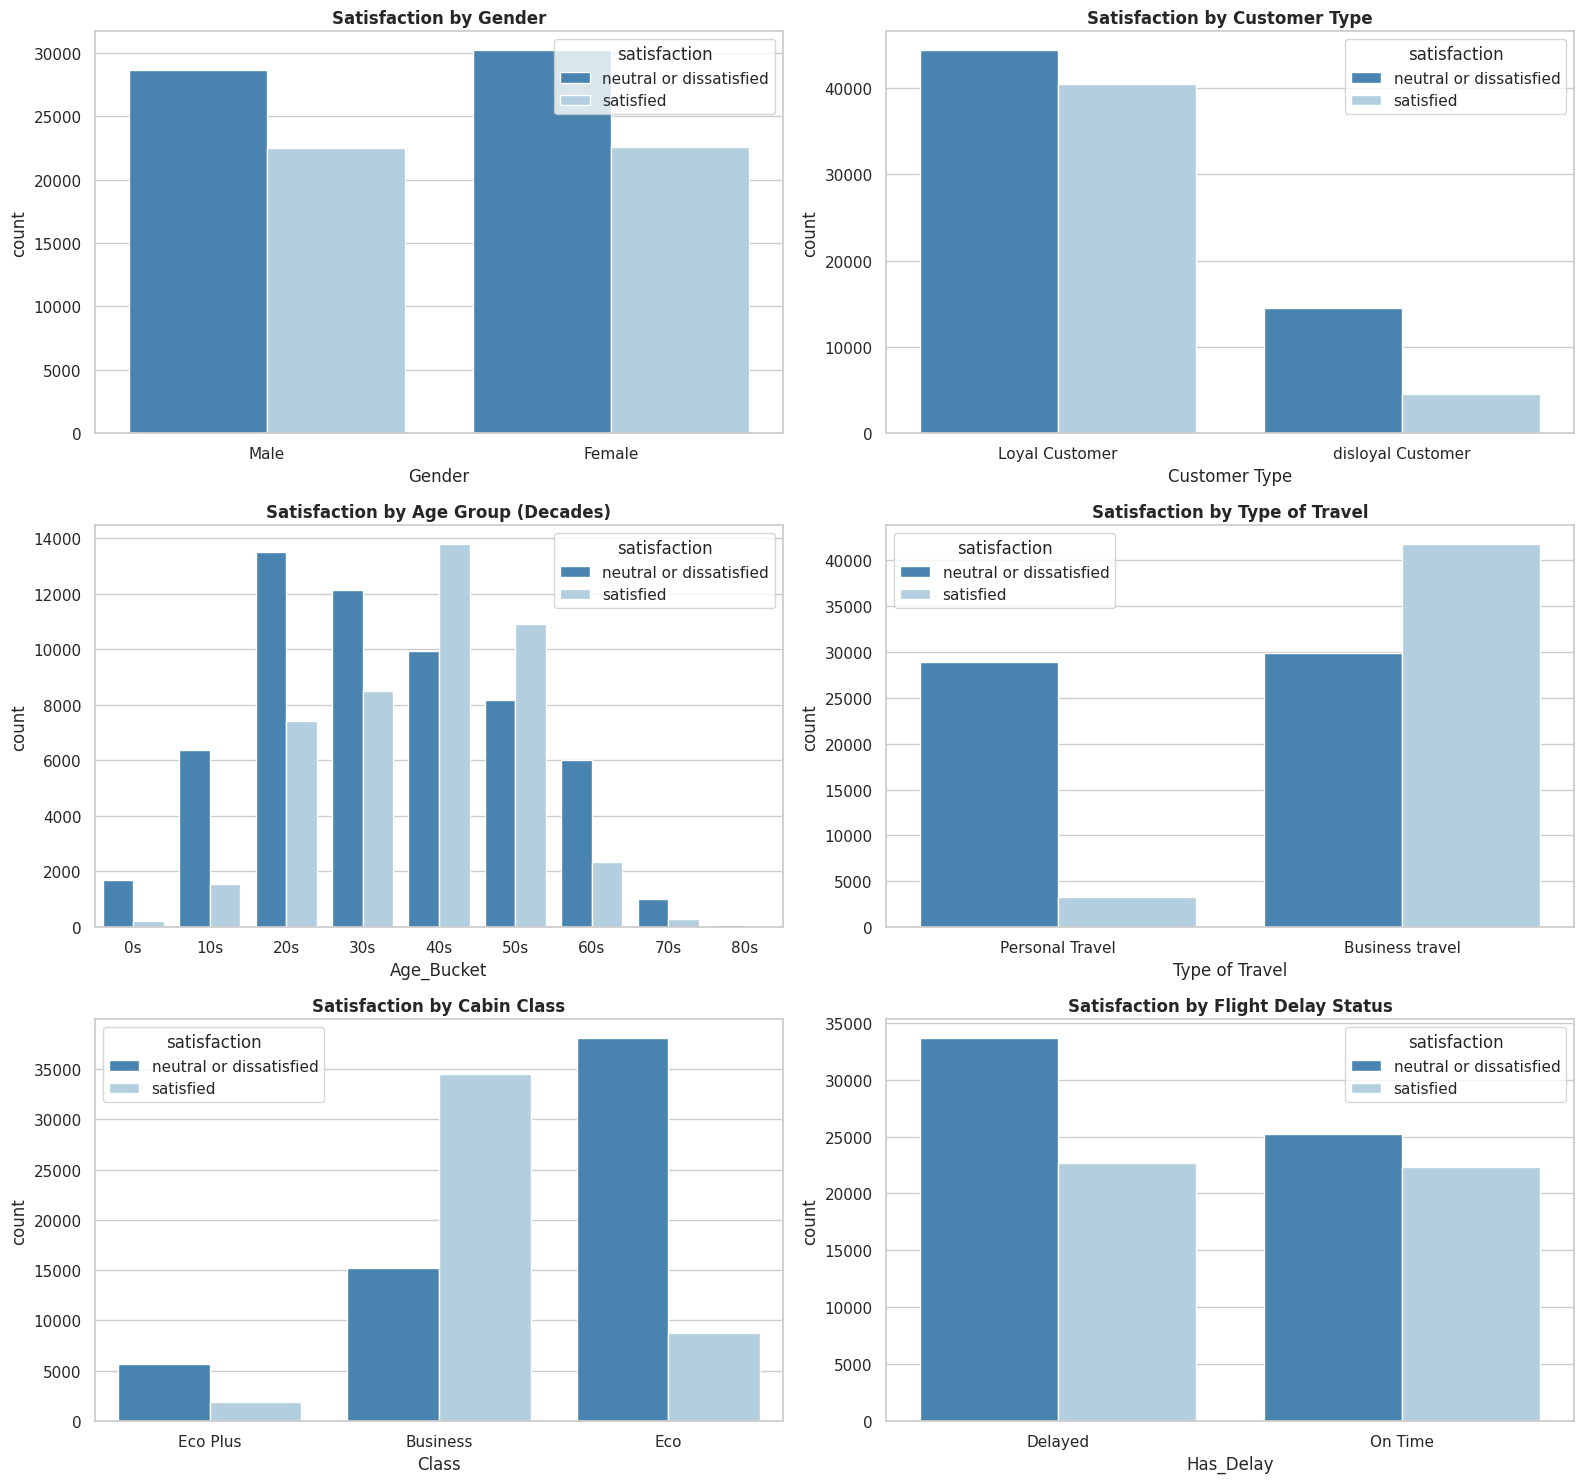

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# 1. Create binned columns in PySpark for comparative visualization  #created age buckets, Distants, and Delayed vs. Ontime for analysis.
eda_df = df.withColumn(
    "Age_Bucket",
    F.concat((F.floor(F.col("Age") / 10) * 10).cast("int"), F.lit("s"))
).withColumn(
    "Distance_Bucket",
    F.concat((F.floor(F.col("Flight Distance") / 500) * 500).cast("int"), F.lit(" - "), ((F.floor(F.col("Flight Distance") / 500) + 1) * 500).cast("int"))
).withColumn(
    "Has_Delay",
    F.when((F.col("Departure Delay in Minutes") > 0) | (F.col("Arrival Delay in Minutes") > 0), "Delayed").otherwise("On Time")
)

# Convert a sample to Pandas for Seaborn plotting
pdf_demo = eda_df.select("Gender", "Customer Type", "Age_Bucket", "Type of Travel", "Class", "Distance_Bucket", "Has_Delay", "satisfaction").toPandas()

# Sort age buckets chronologically
age_order = sorted(pdf_demo['Age_Bucket'].dropna().unique())

# Plot Demographic Breakdowns
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
sns.set_theme(style="whitegrid")

sns.countplot(data=pdf_demo, x='Gender', hue='satisfaction', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Satisfaction by Gender', fontweight='bold')

sns.countplot(data=pdf_demo, x='Customer Type', hue='satisfaction', ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Satisfaction by Customer Type', fontweight='bold')

sns.countplot(data=pdf_demo, x='Age_Bucket', order=age_order, hue='satisfaction', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Satisfaction by Age Group (Decades)', fontweight='bold')

sns.countplot(data=pdf_demo, x='Type of Travel', hue='satisfaction', ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Satisfaction by Type of Travel', fontweight='bold')

sns.countplot(data=pdf_demo, x='Class', hue='satisfaction', ax=axes[2, 0], palette='Blues_r')
axes[2, 0].set_title('Satisfaction by Cabin Class', fontweight='bold')

sns.countplot(data=pdf_demo, x='Has_Delay', hue='satisfaction', ax=axes[2, 1], palette='Blues_r')
axes[2, 1].set_title('Satisfaction by Flight Delay Status', fontweight='bold')

plt.tight_layout()
plt.show()

**Exploratory Data Analysis & Demographic Segmentation:** To identify key drivers of passenger satisfaction, raw operational data was structured in PySpark by binning continuous features into business segments (age brackets, flight distance intervals, and delay status).

**Exploratory Visualization #2 Feature Correlation Matrix with Satisfaction**

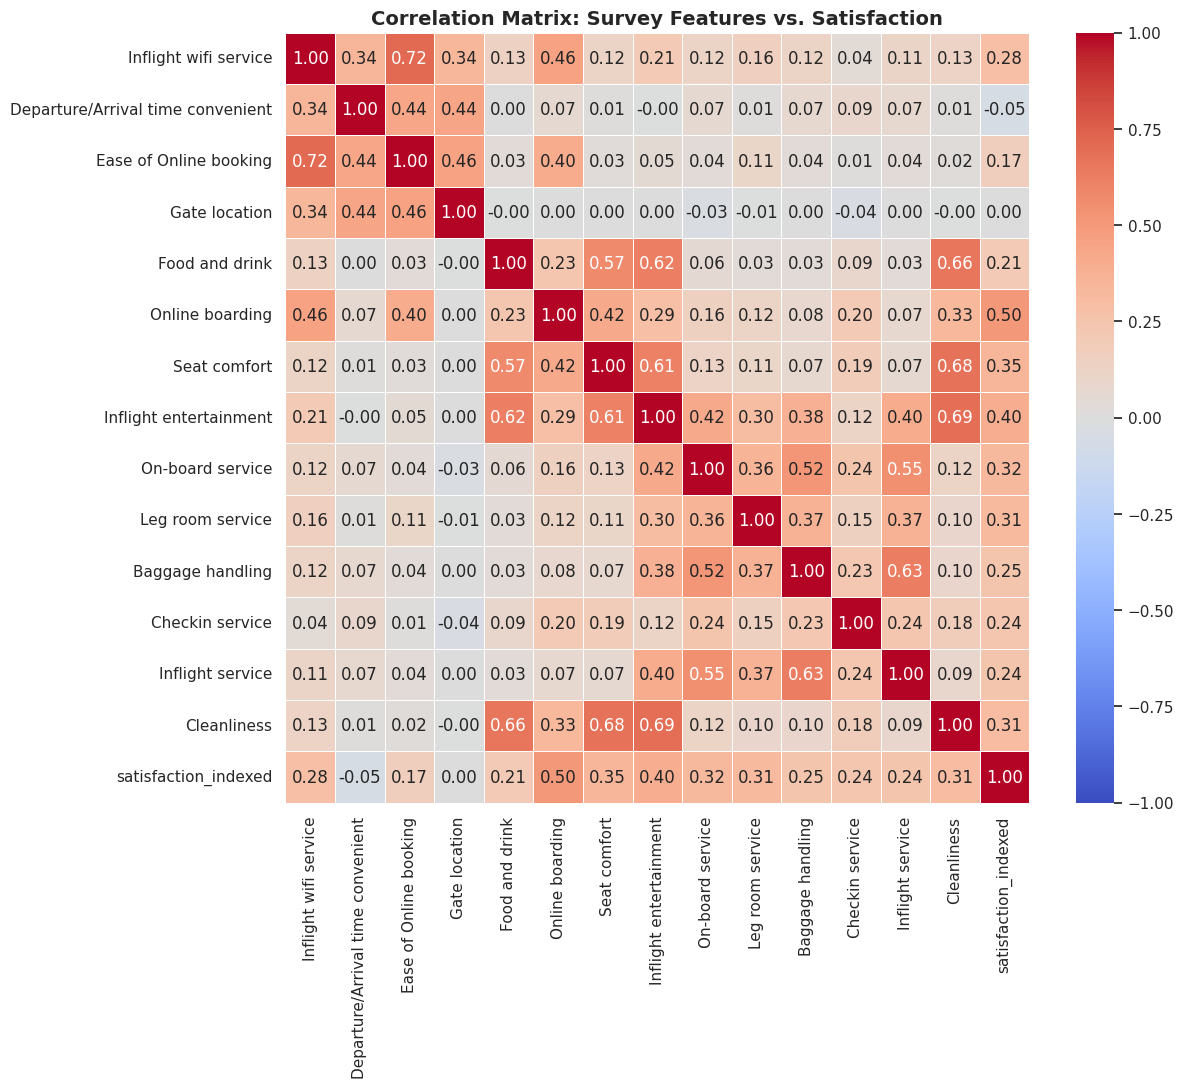

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert survey features + target from pipeline_df to Pandas
survey_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'satisfaction_indexed'
]

# Extract survey sample to calculate correlation matrix
pdf_corr = pipeline_df.select(survey_cols).toPandas()

plt.figure(figsize=(12, 10))
corr = pdf_corr.corr()

# Highlight correlation specifically against satisfaction_indexed
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: Survey Features vs. Satisfaction', fontsize=14, fontweight='bold')
plt.show()

**Notes on the Visualization**

We calculated a correlation matrix across 14 core survey attributes to evaluate how strongly individual service experiences influence overall passenger satisfaction. This analysis would help with feature selection in future models.

# **Exploratory Visualization #3 XGBoost Feature Importance Plot**

/tmp/ipykernel_1584/3158974113.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.head(12), x='Importance', y='Feature', palette='Blues_r')


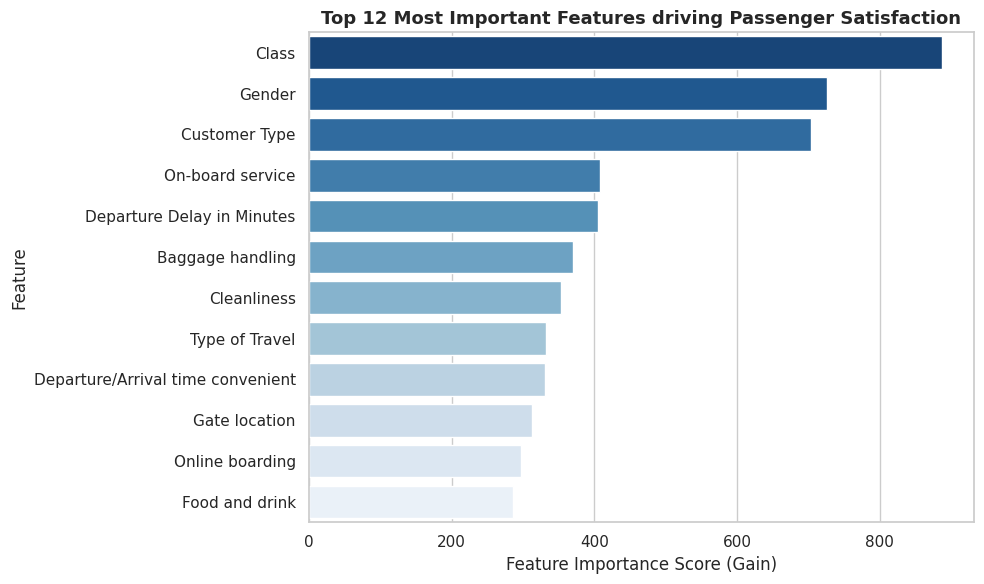

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define feature names in the EXACT order they were passed to VectorAssembler
feature_names = [
    "Gender", "Customer Type", "Age", "Type of Travel", "Class",
    "Flight Distance", "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness",
    "Departure Delay in Minutes", "Arrival Delay in Minutes", "class_encoded"
]

# 2. Extract feature importances
try:
    raw_importances = xgb_model.get_feature_importances()
except AttributeError:
    raw_importances = xgb_model.featureImportances.toArray()

# 3. Handle dictionary vs list/array outputs safely
if isinstance(raw_importances, dict):
    # Parse dict key format (e.g. 'f0' -> 0 or integer key 0)
    parsed_data = []
    for k, v in raw_importances.items():
        idx = int(str(k).replace('f', '')) if str(k).startswith('f') else int(k)
        if idx < len(feature_names):
            parsed_data.append({'Feature': feature_names[idx], 'Importance': float(v)})
    df_importance = pd.DataFrame(parsed_data)
else:
    # Handle numpy array or standard list
    df_importance = pd.DataFrame({
        'Feature': feature_names[:len(raw_importances)],
        'Importance': list(raw_importances)
    })

# 4. Sort top features
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 5. Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance.head(12), x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 12 Most Important Features driving Passenger Satisfaction', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Notes on the visualization:**
Raw XGBoost feature importance vectors were parsed and mapped to their corresponding schema names to isolate the top 12 predictors of customer satisfaction.

# **Exploratory Visualization #4
Satisfaction Breakdown by Travel Class and Passenger Type

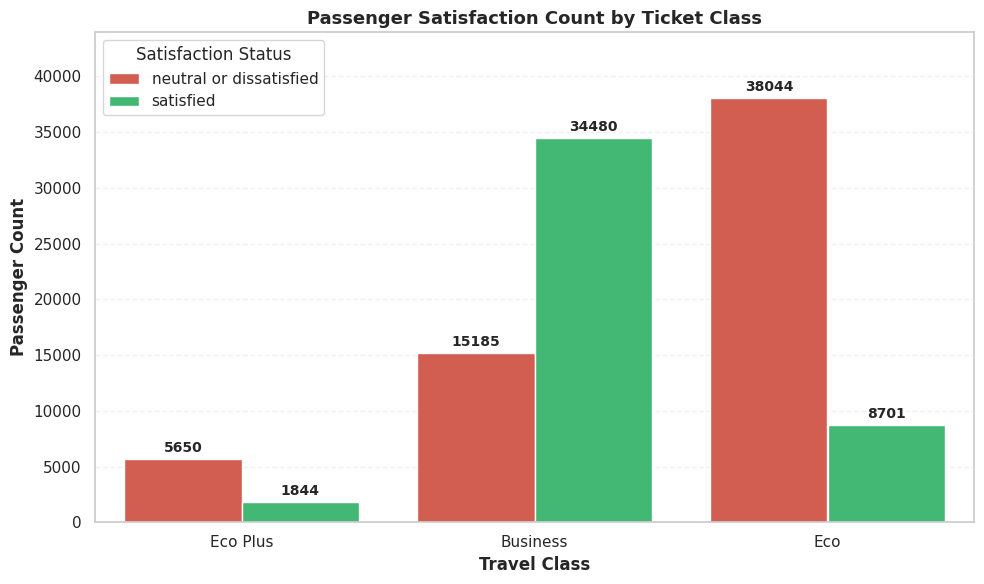

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract segment columns from raw DataFrame `df`
segment_pd = df.select("Class", "Type of Travel", "satisfaction").toPandas()

# 2. Setup figure & axis
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot Grouped Bar Chart
sns.countplot(
    data=segment_pd,
    x='Class',
    hue='satisfaction',
    hue_order=['neutral or dissatisfied', 'satisfied'],
    palette=['#e74c3c', '#2ecc71'],
    ax=ax
)

# 4. Add data labels on top of each bar container
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

# 5. Formatting
plt.title('Passenger Satisfaction Count by Ticket Class', fontsize=13, fontweight='bold')
plt.xlabel('Travel Class', fontweight='bold')
plt.ylabel('Passenger Count', fontweight='bold')
plt.legend(title='Satisfaction Status')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Expand Y-axis slightly so labels don't clip against top frame
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

**Notes on Visualization: **

Visualization of activity by ticket class—note the significant dissatisfaction in the Eco classes.

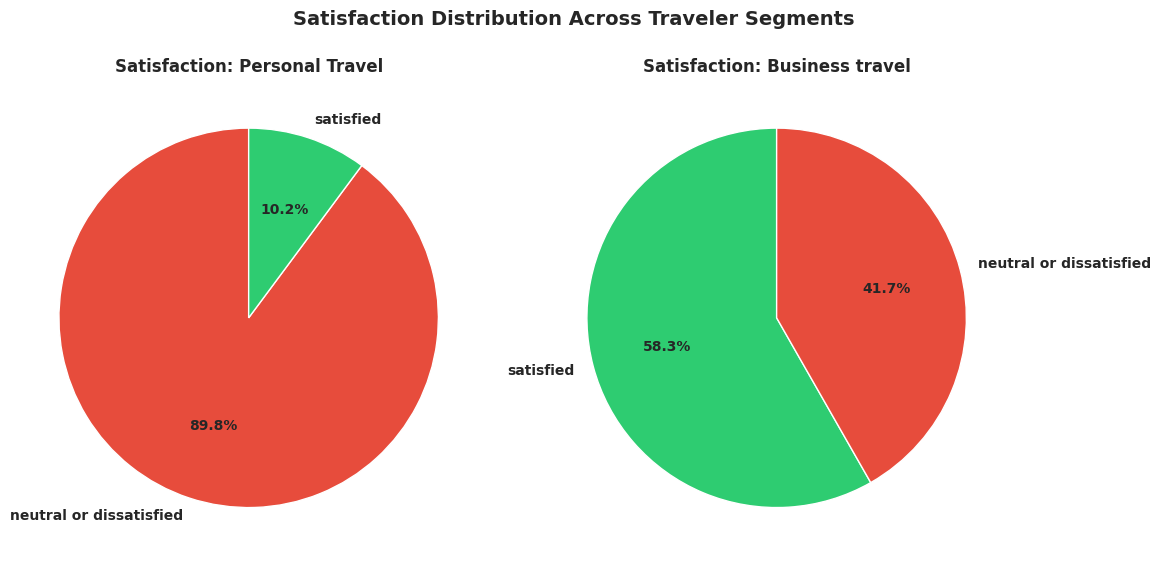

In [ ]:
import matplotlib.pyplot as plt

# 1. Select relevant columns and convert to Pandas
pdf_traveler = df.select("Type of Travel", "satisfaction").toPandas()

# 2. Clean string columns (strip whitespace to avoid mapping mismatches)
pdf_traveler['satisfaction'] = pdf_traveler['satisfaction'].astype(str).str.strip()
pdf_traveler['Type of Travel'] = pdf_traveler['Type of Travel'].astype(str).str.strip()

# 3. Get unique traveler types
traveler_types = pdf_traveler['Type of Travel'].dropna().unique()

# 4. Strict label-to-color mapping
color_map = {
    'satisfied': '#2ecc71',                  # Green
    'neutral or dissatisfied': '#e74c3c'      # Red
}

# 5. Setup subplots
fig, axes = plt.subplots(1, len(traveler_types), figsize=(12, 6))

for i, t_type in enumerate(traveler_types):
    subset = pdf_traveler[pdf_traveler['Type of Travel'] == t_type]
    counts = subset['satisfaction'].value_counts()

    # Map each label to its exact color
    slice_colors = [color_map[label] for label in counts.index]

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=slice_colors,
        textprops={'fontsize': 10, 'weight': 'bold'}
    )
    axes[i].set_title(f'Satisfaction: {t_type}', fontsize=12, fontweight='bold')

plt.suptitle('Satisfaction Distribution Across Traveler Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Notes on Visualization
A significant amount of travelers that were ECO were also personal travelers.   Almost universally negative.

# **Exploratory Visualization #5 **

Table of demographic data of total passengers age and satisfaction rates. This table might indicate that our data source is not real.

In [ ]:
from pyspark.sql.functions import col, avg, count, when, round

# Aggregate demographic summary statistics
demo_summary = df.groupBy("Gender", "Customer Type").agg(
    count("*").alias("Total_Passengers"),
    round(avg("Age"), 1).alias("Avg_Age"),
    round(avg(when(col("satisfaction").contains("satisfied") & ~col("satisfaction").contains("neutral"), 1).otherwise(0)) * 100, 1).alias("Satisfaction_Rate_%")
)

demo_summary.show()

+------+-----------------+----------------+-------+-------------------+
|Gender|    Customer Type|Total_Passengers|Avg_Age|Satisfaction_Rate_%|
+------+-----------------+----------------+-------+-------------------+
|Female|disloyal Customer|           10269|   30.4|               22.6|
|  Male|   Loyal Customer|           42465|   41.4|               47.9|
|Female|   Loyal Customer|           42458|   41.4|               47.6|
|  Male|disloyal Customer|            8712|   30.3|               24.9|
+------+-----------------+----------------+-------+-------------------+



# Limitations, Future Work, and Conclusion

### Limitations

#### Missing Contextual & Qualitative Data
* **Limited Scope:** The survey covers 22 predictor dimensions on a 1–5 scale, but lacks key contextual features:
* **Socio-Demographic & Seasonal Factors:** No income, household size, timestamp, or seasonality data.
* **Commercial Drivers:** Missing ticket pricing, loyalty program tiers, and specific route/destination data.
* **No Qualitative Feedback:** Lacks open-ended text comments, preventing NLP sentiment analysis from uncovering the "why" behind low scores.

#### Missing Data Imputation
* **Arrival Delay Nulls:** Found 310 missing values in Arrival Delay in Minutes (103,594 populated vs. 103,904 total), while all other 22 features were complete.
* **Bias Mitigation:** Required explicit strategy decisions (such as median imputation) to resolve missing values without introducing model bias.

#### Granularity Loss from Feature Binning
* **Skewed Continuous Metrics:** Departure delay had a 0.0-minute median but spiked to 1,592 minutes (~26.5 hours), while flight distance spanned 31 to 4,983 miles.
* **Trade-off:** Binning continuous metrics improved scannability for business reporting, but removed subtle variance that high-resolution models rely on.







### Future Work

While the models demonstrate exceptional predictive power, converting these insights into actionable business decisions and a richer understanding of the drivers of satisfaction requires some enhancements.

* **Incorporate NLP & Unstructured Text:** Integrate Spark NLP to analyze passenger comments, uncovering the qualitative "why" behind low satisfaction ratings.

* **Enrich Datasets:** Add additional data (including seasonal travel flags, timestamps, and regional demographics) to identify if dissatisfaction spikes during specific time windows.

* **Integrate Financial ROI Metrics:** Build a business logic layer that links model predictions to real financial costs and opportunities.

* **Automate Model Optimization:** (PySpark MLlib CrossValidator and MLflow) Systematically tune and maintain peak accuracy over time.

## Conclusion

### Approach Summary & Architecture
We designed and deployed an end-to-end data pipeline using PySpark to ingest, clean, transform, and model **103,904 airline passenger survey records** across **22 predictor dimensions**.

* **Scalable Ingestion & Portability:** Implemented automated environment detection to handle configuration dynamically to handle different environments. (Google Colab).
* **Pipeline Engineering & Schema:** Enforced strict schema definitions during ingestion, resolved missing values in Arrival Delay in Minutes using PySpark's median Imputer, and standardized input types across all 22 survey dimensions.
* **Feature Engineering & Transformation:** Applied Bucketizer for feature binning on skewed continuous metrics and assembled features using VectorAssembler to optimize data structures for PySpark MLlib and XGBoost pipelines.

### Key Discoveries & Model Performance
* **Peak Predictive Accuracy:** Boosted tree models achieved an **AUC near 1.0**, proving that passenger dissatisfaction is tied to distinct patterns rather than random noise.

* **Primary Disatisfaction Drivers:** Feature importance metrics identified Wi-Fi quality, seat comfort, and flight delay duration as the strongest predictors of churn, heavily concentrated in Economy class segments.

### Evaluation of Data Engineering Trade-Offs & Architecture


* **Engineering Trade-Offs & Architectural Limitations:**
  * **Granularity Loss:** Binning continuous features simplified reporting, but wiped out micro-variances (e.g., flight distances spanning 31 to 4,983 miles and delays reaching 1,592 minutes) that granular engines could leverage.

  * **Schema Limitations:** The dataset lacks key contextual metadata—such as seasonal timestamps, route origin/destination pairs, pricing data, and unstructured passenger feedback required for NLP pipelines.